In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

# Path to the zip file
zip_file_path = '/content/drive/MyDrive/images_final.zip'

# Destination folder to extract the contents
destination_folder = '/content/image'

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_folder)

print(f"Files have been extracted to: {destination_folder}")


Files have been extracted to: /content/image


In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [4]:
import base64
import io
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn import init

In [5]:
# Ensure every computation happens on the GPU when available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'

In [6]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [8]:
# df_stories = pd.read_csv("/content/drive/MyDrive/coco_30k_with_LongDesc_final.csv")
df_stories = pd.read_csv("/content/mukund_coco_30k_with_LongDesc_final.csv")

In [9]:
df_img_paths = pd.read_csv("/content/drive/MyDrive/image_path_dataset_final.csv")

In [10]:
merged_df = pd.merge(df_stories, df_img_paths, on='image_id', how='inner')  # You can use 'inner', 'outer', 'left', or 'right' for different join types.
merged_df.shape

(28154, 4)

In [11]:
df = merged_df.drop(['image_id', 'captions'], axis = 1)

In [12]:
df.rename(columns={'LongDesc': 'caption', 'image_path': 'image'}, inplace=True)


In [13]:
df.head()

,caption,image
0,"There is a man wearing a bright red helmet, zo...",./coco_subset/images/000000391895.jpg
1,"In a bright kitchen, a lady with a funny net o...",./coco_subset/images/000000522418.jpg
2,There is a happy boy with a bright umbrella. H...,./coco_subset/images/000000184613.jpg
3,There is a little boy at school sitting in fro...,./coco_subset/images/000000318219.jpg
4,"In a big room, there are many computers lined ...",./coco_subset/images/000000554625.jpg


In [14]:
# Update the image paths using vectorized string operations
new_prefix = "/content/image/images"
df["image"] = new_prefix + "/" + df["image"].str.split("/").str[-1]

In [15]:
df.head()

,caption,image
0,"There is a man wearing a bright red helmet, zo...",/content/image/images/000000391895.jpg
1,"In a bright kitchen, a lady with a funny net o...",/content/image/images/000000522418.jpg
2,There is a happy boy with a bright umbrella. H...,/content/image/images/000000184613.jpg
3,There is a little boy at school sitting in fro...,/content/image/images/000000318219.jpg
4,"In a big room, there are many computers lined ...",/content/image/images/000000554625.jpg


In [16]:
df.shape

(28154, 2)

In [17]:
#himanshu

# Extract all text from the 'caption' column
all_text = ''.join(df['caption'].fillna('').tolist())  # Fill NaNs with empty strings

# Extract unique characters from the 'caption' column
chars = sorted(list(set(all_text)))
chars.append('<pad>')
chars.append('<start>')

# Create mappings
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

# Verify that all characters in all_text are mapped
for char in all_text:
    assert char in stoi, f"Character '{char}' is not in stoi!"

# Functions for encoding and decoding
encode = lambda s: [stoi[c] for c in s]  # Converts string to list of integers
decode = lambda l: ''.join([itos[i] for i in l])  # Converts list of integers back to string


# Vocabulary size
vocab_size = len(stoi.keys())

# Debugging prints
print(f"Unique characters: {chars}")
print(f"stoi: {stoi}")
print(f"itos: {itos}")
print(f"Vocabulary size: {vocab_size}")


Unique characters: ['\n', '\r', ' ', '!', '"', '&', "'", ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'é', 'ñ', '–', '—', '’', '“', '”', '🍕', '<pad>', '<start>']
stoi: {'\n': 0, '\r': 1, ' ': 2, '!': 3, '"': 4, '&': 5, "'": 6, ',': 7, '-': 8, '.': 9, '/': 10, '0': 11, '1': 12, '2': 13, '3': 14, '4': 15, '5': 16, '6': 17, '7': 18, '8': 19, '9': 20, ':': 21, ';': 22, '?': 23, 'A': 24, 'B': 25, 'C': 26, 'D': 27, 'E': 28, 'F': 29, 'G': 30, 'H': 31, 'I': 32, 'J': 33, 'K': 34, 'L': 35, 'M': 36, 'N': 37, 'O': 38, 'P': 39, 'Q': 40, 'R': 41, 'S': 42, 'T': 43, 'U': 44, 'V': 45, 'W': 46, 'X': 47, 'Y': 48, 'Z': 49, 'a': 50, 'b': 51, 'c': 52, 'd': 53, 'e': 54, 'f': 55, 'g': 56, 'h': 57, 'i': 58, 'j': 59,

In [18]:
type(stoi['<start>'])

int

In [19]:
import torch
import torch.nn as nn

class PatchEmbeddings(nn.Module):
    def __init__(self, img_size=224, patch_size=16, hidden_dim=512):
        super().__init__()

        # Store the input image size
        self.img_size = img_size

        # Store the size of each patch
        self.patch_size = patch_size

        # Calculate the total number of patches
        self.num_patches = (img_size // patch_size) ** 2

        # First convolutional layer to extract patch embeddings
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=hidden_dim,
                               kernel_size=patch_size, stride=patch_size)

        # Add more layers to increase parameters
        self.conv2 = nn.Conv2d(in_channels=hidden_dim, out_channels=hidden_dim,
                               kernel_size=3, stride=1, padding=1)
        self.norm1 = nn.BatchNorm2d(hidden_dim)
        self.activation1 = nn.ReLU()



        # Optionally, add a final fully connected layer for further embedding refinement
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, X):
        # First convolutional layer
        X = self.conv1(X)

        # Additional convolutional layers with normalization and activation
        X = self.conv2(X)
        X = self.norm1(X)
        X = self.activation1(X)

        # X = self.conv3(X)
        # X = self.norm2(X)
        # X = self.activation2(X)

        # Flatten the spatial dimensions (height and width) of the patch embeddings
        X = X.flatten(2)

        # Transpose the dimensions to obtain the shape [batch_size, num_patches, hidden_dim]
        X = X.transpose(1, 2)

        # Apply the fully connected layer
        X = self.fc(X)

        return X


In [20]:
#testing
img_size, patch_size,  num_hiddens, batch_size = 224, 16, 512, 32
patch_embeddings = PatchEmbeddings(img_size, patch_size, num_hiddens )
X = torch.zeros(batch_size, 3, img_size, img_size)
patch_embeddings(X).shape

torch.Size([32, 196, 512])

In [21]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in patch_embeddings.parameters() if p.requires_grad)/1_000_000
# num_params_millions = num_params / 1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 3.017216


In [22]:
#swapping linear for lazy linear for simplicity. Lazylinear can accept any arbitrary input dimension without having it specified

class MLP(nn.Module):
    def __init__(self, n_embd, dropout=0.1, is_decoder=True):
        super().__init__()

        # Define the layers of the MLP
        layers = [
            # First linear layer that expands the input dimension from n_embd to 4 * n_embd
            nn.Linear(n_embd, 4 * n_embd),

            # Activation function: ReLU if is_decoder is True, else GELU
            nn.ReLU() if is_decoder else nn.GELU(),

            # Second linear layer that projects the intermediate dimension back to n_embd
            nn.Linear(4 * n_embd, n_embd),

            # Dropout layer for regularization
            nn.Dropout(dropout)
        ]

        # Create a sequential container to hold the layers
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Pass the input through the MLP layers
        return self.net(x)


In [23]:
#For the sake of this example consider embedding size to be 128
n_embd = 128
testmlp = MLP(n_embd)
mlp_input = torch.zeros(batch_size, 3, n_embd)
testmlp_out = testmlp(mlp_input)
testmlp_out.shape

torch.Size([32, 3, 128])

In [24]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in testmlp.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 0.131712


In [25]:
class Head(nn.Module):
    def __init__(self, n_embd, head_size, dropout=0.1, is_decoder=False):
        super().__init__()

        # Linear layer for key projection
        self.key = nn.Linear(n_embd, head_size, bias=False)

        # Linear layer for query projection
        self.query = nn.Linear(n_embd, head_size, bias=False)

        # Linear layer for value projection
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

        # Flag indicating whether this head is used in the decoder
        self.is_decoder = is_decoder

    def forward(self, x):
        # Get the batch size (B), sequence length (T), and embedding dimension (C) from the input tensor
        B, T, C = x.shape

        # Compute key, query, and value projections
        k = self.key(x)   # Shape: [B, T, head_size]
        q = self.query(x) # Shape: [B, T, head_size]
        v = self.value(x) # Shape: [B, T, head_size]

        wei = q @ k.transpose(-2, -1) * (C ** -0.5) # Shape: [B, T, T]


        if self.is_decoder:
            # If this head is used in the decoder, apply a causal mask to the attention scores
            # to prevent attending to future positions
            tril = torch.tril(torch.ones(T, T, dtype=torch.bool, device=x.device))
            wei = wei.masked_fill(tril == 0, float('-inf'))

        # Apply softmax to the attention scores to obtain attention probabilities
        wei = F.softmax(wei, dim=-1) # Shape: [B, T, T]

        # Apply dropout to the attention probabilities for regularization
        wei = self.dropout(wei)

        # Perform weighted aggregation of values using the attention probabilities
        out = wei @ v # Shape: [B, T, head_size]

        return out


In [26]:
#Example values for testing
n_embd, head_size, batch_size = 128, 16, 32

testhead = Head(n_embd, head_size)
head_input = torch.zeros(batch_size, 3, n_embd)
testhead_out = testhead(head_input)
testhead_out.shape # (B, T,H_size)

torch.Size([32, 3, 16])

In [27]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in testhead.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 0.006144


In [28]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
        super().__init__()

        # Ensure that the embedding dimension is divisible by the number of heads
        assert n_embd % num_heads == 0, "n_embd must be divisible by num_heads"

        # Create a ModuleList of attention heads
        self.heads = nn.ModuleList([
            Head(n_embd, n_embd // num_heads, dropout, is_decoder)
            for _ in range(num_heads)
        ])

        # Linear layer for projecting the concatenated head outputs
        self.proj = nn.Linear(n_embd, n_embd)

        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Apply each attention head to the input tensor
        head_outputs = [h(x) for h in self.heads]

        # Concatenate the outputs from all heads along the last dimension
        out = torch.cat(head_outputs, dim=-1)

        # Apply the projection layer to the concatenated outputs
        out = self.proj(out)

        # Apply dropout to the projected outputs for regularization
        out = self.dropout(out)

        return out


In [29]:
#Example values for testing
n_embd, n_head = 128, 8
testmha = MultiHeadAttention(n_embd, n_head)
head_input = torch.zeros(batch_size, 3, n_embd)
testmha_out = testmha(head_input)
testmha_out.shape # (B, T,H_size*n_heads = n_embed)

torch.Size([32, 3, 128])

In [30]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in testmha.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 0.065664


In [31]:
class Block(nn.Module):
    def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
        super().__init__()

        # Layer normalization for the input to the attention layer
        self.ln1 = nn.LayerNorm(n_embd)

        # Multi-head attention module
        self.attn = MultiHeadAttention(n_embd, num_heads, dropout, is_decoder)

        # Layer normalization for the input to the FFN
        self.ln2 = nn.LayerNorm(n_embd)

        # Feed-forward neural network (FFN)
        self.ffn = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # Expand the dimension
            nn.GELU(),  # Activation function
            nn.Linear(4 * n_embd, n_embd),  # Project back to the original dimension
        )

    def forward(self, x):
        original_x = x  # Save the input for the residual connection

        # Apply layer normalization to the input
        x = self.ln1(x)

        # Apply multi-head attention
        attn_output = self.attn(x)

        # Add the residual connection (original input) to the attention output
        x = original_x + attn_output

        # Apply layer normalization to the input to the FFN
        x = self.ln2(x)

        # Apply the FFN
        ffn_output = self.ffn(x)

        # Add the residual connection (input to FFN) to the FFN output
        x = x + ffn_output

        return x

In [32]:
#Example values for testing
n_embd, head_size, batch_size = 128, 16, 32

testblock = Block(n_embd, n_head)
block_input = torch.zeros(batch_size, 3, n_embd)
testblock_out = testblock(block_input)
testblock_out.shape

torch.Size([32, 3, 128])

In [33]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in testblock.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 0.197888


Now all this can be be put together to implement a Vision Transformer

In [34]:
class ViT(nn.Module):
    def __init__(self, img_size, patch_size, num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout):
        super().__init__()

        # Patch embedding layer to convert the input image into patches
        self.patch_embedding = PatchEmbeddings(img_size, patch_size, num_hiddens)

        # Learnable classification token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))

        # Calculate the number of patches
        num_patches = (img_size // patch_size) ** 2

        # Learnable position embedding
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, num_hiddens))

        # Dropout layer for the embeddings
        self.dropout = nn.Dropout(emb_dropout)

        # Stack of transformer blocks
        self.blocks = nn.ModuleList([Block(num_hiddens, num_heads, blk_dropout, is_decoder=False) for _ in range(num_blks)])

        # Layer normalization for the final representation
        self.layer_norm = nn.LayerNorm(num_hiddens)

    def forward(self, X):
        # Convert the input image into patch embeddings
        x = self.patch_embedding(X)

        # Expand the classification token to match the batch size
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)

        # Concatenate the classification token with the patch embeddings
        x = torch.cat((cls_tokens, x), dim=1)

        # Add the position embedding to the patch embeddings
        x += self.pos_embedding

        # Apply dropout to the embeddings
        x = self.dropout(x)

        # Pass the embeddings through the transformer blocks
        for block in self.blocks:
            x = block(x)

        # Apply layer normalization to the final representation
        x = self.layer_norm(x[:, 0])

        return x


In [35]:
#For purposes of testing
img_size, patch_size, num_hiddens, n_head, num_blks, dropout = 224, 16, 512, 8, 3, 0.1

testvit = ViT(img_size, patch_size, num_hiddens, n_head, num_blks, dropout, dropout)
vit_input = torch.zeros(batch_size, 3, img_size, img_size)
testvit_out = testvit(vit_input)
testvit_out.shape

torch.Size([32, 512])

In [36]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in testvit.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 12.57216


In [37]:
class MultiModalProjector(nn.Module):
    def __init__(self, n_embd, image_embed_dim, dropout=0.1):
        super().__init__()

        # Define the projection network
        self.net = nn.Sequential(
            # Linear layer to expand the image embedding dimension
            nn.Linear(image_embed_dim, 4 * image_embed_dim),

            # GELU activation function
            nn.GELU(),

            # Linear layer to project the expanded image embeddings to the text embedding dimension
            nn.Linear(4 * image_embed_dim, n_embd),

            # Dropout layer for regularization
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Pass the input through the projection network
        x = self.net(x)
        return x


In [38]:
#Example values for testing
n_embd,num_hiddens = 128, 512

testmmp = MultiModalProjector(n_embd,num_hiddens)
mmp_input = testvit_out
testmmp_out = testmmp(mmp_input)
testmmp_out.shape

torch.Size([32, 128])

In [39]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in testmmp.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 1.312896


In [40]:
class DecoderLanguageModel(nn.Module):
    def __init__(self, n_embd, image_embed_dim, vocab_size, num_heads, n_layer, use_images=False, max_seq_len=5000):
        super().__init__()

        self.use_images = use_images
        self.max_seq_len = max_seq_len # Store max_seq_len for later use


        # Token embedding table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)

        # Position embedding table
        self.position_embedding_table = nn.Embedding(max_seq_len, n_embd) # previously 1000

        if use_images:
            # Image projection layer to align image embeddings with text embeddings
            self.image_projection = MultiModalProjector(n_embd, image_embed_dim)

        # Stack of transformer decoder blocks
        self.blocks = nn.Sequential(*[Block(n_embd, num_heads, is_decoder=True) for _ in range(n_layer)])

        # Final layer normalization
        self.ln_f = nn.LayerNorm(n_embd)

        # Language modeling head
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, image_embeds=None, targets=None):
        # Get token embeddings from the input indices
        tok_emb = self.token_embedding_table(idx)

        if self.use_images and image_embeds is not None:
            # Project and concatenate image embeddings with token embeddings
            img_emb = self.image_projection(image_embeds).unsqueeze(1)
            tok_emb = torch.cat([img_emb, tok_emb], dim=1)

        # Get position embeddings, ensuring sequence length doesn't exceed the maximum
        seq_len = tok_emb.size(1)
        pos_emb = self.position_embedding_table(torch.arange(min(seq_len, self.max_seq_len), device=device).long()).unsqueeze(0) # clamped sequence length and added .long() for type safety

        # Add position embeddings to token embeddings
        x = tok_emb + pos_emb

        # Pass through the transformer decoder blocks
        x = self.blocks(x)

        # Apply final layer normalization
        x = self.ln_f(x)

        # Get the logits from the language modeling head
        logits = self.lm_head(x)

        if targets is not None:
            if self.use_images and image_embeds is not None:
                # Prepare targets by concatenating a dummy target for the image embedding
                batch_size = idx.size(0)
                targets = torch.cat([torch.full((batch_size, 1), -100, dtype=torch.long, device=device), targets], dim=1)

            # Compute the cross-entropy loss
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-100)
            return logits, loss

        return logits


    def generate(self, idx, image_embeds, max_new_tokens):
        # Get the batch size and sequence length
        B, T = idx.shape

        # Initialize the generated sequence with the input indices
        generated = idx

        if self.use_images and image_embeds is not None:
            # Project and concatenate image embeddings with token embeddings
            img_emb = self.image_projection(image_embeds).unsqueeze(1)
            current_output = torch.cat([img_emb, self.token_embedding_table(idx)], dim=1)
        else:
            current_output = self.token_embedding_table(idx)

        # Generate new tokens iteratively
        for i in range(max_new_tokens):
            # Get the current sequence length
            T_current = current_output.size(1)

            # Get position embeddings for the current sequence length
            current_pos_emb = self.position_embedding_table(torch.arange(T_current, device=device)).unsqueeze(0)

            # Add position embeddings to the current output
            current_output += current_pos_emb

            # Pass through the transformer decoder blocks
            for block in self.blocks:
                current_output = block(current_output)

            # Get the logits for the last token
            logits = self.lm_head(current_output[:, -1, :])

            # Apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample the next token based on the probabilities
            idx_next = torch.multinomial(probs, num_samples=1)

            # Concatenate the generated token to the generated sequence
            generated = torch.cat((generated, idx_next), dim=1)

            # Get the embeddings for the generated token
            idx_next_emb = self.token_embedding_table(idx_next)

            # Concatenate the generated token embeddings to the current output
            current_output = torch.cat((current_output, idx_next_emb), dim=1)

        return generated

In [41]:
# I use n_layer to represent number of decoder transformer blocks and n_blks for the vision encoder to avoid confusion
model = DecoderLanguageModel(n_embd=128, image_embed_dim=512, vocab_size=1000, num_heads=8, n_layer=6, use_images=True)
model.to(device)
# Dummy input
B, T = 10, 50
idx = torch.randint(0, 1000, (B, T)).to(device)
image_embeds = torch.randn(B, 512).to(device)  # Assume image_embed_dim is 256

targets = torch.randint(0, vocab_size, (B, T)).to(device)  # Only if you want to compute loss

# Test forward pass
# Check if you need to calculate loss by providing targets
if targets is not None:
    logits, loss = model(idx, image_embeds, targets)
    print(f"Logits shape: {logits.shape}, Loss: {loss}")
else:
    logits = model(idx, image_embeds)  # Call without targets
    print(f"Logits shape: {logits.shape}")

# Test generation
generated = model.generate(idx, image_embeds, max_new_tokens=20)
print(f"Generated sequence shape: {generated.shape}")



Logits shape: torch.Size([10, 51, 1000]), Loss: 7.071829795837402
Generated sequence shape: torch.Size([10, 70])


In [42]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 3.39748


In [43]:
class VisionLanguageModel(nn.Module):
    def __init__(self, n_embd, image_embed_dim, vocab_size, n_layer, img_size, patch_size, num_heads, num_blks, emb_dropout, blk_dropout):
        super().__init__()

        # Set num_hiddens equal to image_embed_dim
        num_hiddens = image_embed_dim

        # Assert that num_hiddens is divisible by num_heads
        assert num_hiddens % num_heads == 0, "num_hiddens must be divisible by num_heads"

        # Initialize the vision encoder (ViT)
        self.vision_encoder = ViT(img_size, patch_size, num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout)

        # Initialize the language model decoder (DecoderLanguageModel)
        self.decoder = DecoderLanguageModel(n_embd, image_embed_dim, vocab_size, num_heads, n_layer, use_images=True)

    def forward(self, img_array, idx, targets=None):
        # Get the image embeddings from the vision encoder
        image_embeds = self.vision_encoder(img_array)

        # Check if the image embeddings are valid
        if image_embeds.nelement() == 0 or image_embeds.shape[1] == 0:
            raise ValueError("Something is wrong with the ViT model. It's returning an empty tensor or the embedding dimension is empty.")

        if targets is not None:
            # If targets are provided, compute the logits and loss
            logits, loss = self.decoder(idx, image_embeds, targets)
            return logits, loss
        else:
            # If targets are not provided, compute only the logits
            logits = self.decoder(idx, image_embeds)
            return logits

    def generate(self, img_array, idx, max_new_tokens):
        # Get the image embeddings from the vision encoder
        image_embeds = self.vision_encoder(img_array)

        # Check if the image embeddings are valid
        if image_embeds.nelement() == 0 or image_embeds.shape[1] == 0:
            raise ValueError("Something is wrong with the ViT model. It's returning an empty tensor or the embedding dimension is empty.")

        # Generate new tokens using the language model decoder
        generated_tokens = self.decoder.generate(idx, image_embeds, max_new_tokens)
        return generated_tokens

In [44]:
image_embed_dim = num_hiddens

In [45]:
n_layer, block_size =  6, 32

# Initialize the model
model = VisionLanguageModel(n_embd, image_embed_dim, vocab_size,  n_layer, img_size, patch_size, n_head, num_blks, dropout, dropout)
model.to(device)

# Create dummy data with correct dimensions
dummy_img = torch.randn(1, 3, img_size, img_size).to(device)  # Correct shape for image input
dummy_idx = torch.randint(0, vocab_size, (1, block_size)).to(device)  # Correct shape for text input

# Forward pass to initialize all parameters
try:
    output = model(dummy_img, dummy_idx)  # Output for debugging
    print("Output from initialization forward pass:", output)
except RuntimeError as e:
    print(f"Runtime Error during forward pass: {str(e)}")
    print("Check layer configurations and input shapes.")

Output from initialization forward pass: tensor([[[ 0.4291, -1.1472,  0.1016,  ...,  0.2811, -0.4762, -0.0434],
         [ 0.7363, -0.4669,  0.4365,  ...,  0.0902,  0.2578,  1.4576],
         [ 0.8226, -0.2000, -0.6000,  ...,  1.0736,  1.6190, -0.0673],
         ...,
         [ 0.2292,  0.5727, -0.8570,  ..., -0.8161,  1.3768,  0.5140],
         [-0.2133,  0.3431, -1.2635,  ...,  0.0092, -0.7527, -0.2871],
         [ 0.3087, -0.0472,  0.7995,  ...,  0.0439,  1.3748,  0.6497]]],
       device='cuda:0', grad_fn=<ViewBackward0>)


In [46]:
from PIL import Image
from torchvision import transforms

def jpg_to_tensor(file_path, img_size=224):

    # Open the image file
    pil_image = Image.open(file_path)

    # Ensure the image is in RGB format
    if pil_image.mode != 'RGB':
        pil_image = pil_image.convert('RGB')
    # print("SHAPE of rgb image is ", pil_image.size)
    # Define preprocessing transforms
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),  # Resize to desired dimensions
        transforms.ToTensor(),                   # Convert to tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
    ])

    # Apply transforms and return the tensor
    # print("SHAPE of tensor is ", transform(pil_image).shape)
    return transform(pil_image).unsqueeze(0)


In [47]:
#Adjusting the data loader from makemore for multimodal data
def get_batch(df, batch_size, split='train', img_size=224, val_batch_size = 8):
    # Split data into training and validation sets
    n = int(0.9 * len(df))  # first 90% will be train, rest val
    df_train = df.iloc[:n]
    df_val = df.iloc[n:]
    data = df_train if split == 'train' else df_val
    batch_size = batch_size if split == 'train' else val_batch_size
    replace = False if split == 'train' else True
    batch = data.sample(n=batch_size, replace=replace)

    images = torch.cat([jpg_to_tensor(img, img_size) for img in batch['image']], dim=0).to(device)
    # print("shape of image is ", images.shape)
    text_indices = [torch.tensor(encode(desc), dtype=torch.long) for desc in batch['caption']]
    text_indices = [torch.cat([torch.tensor([stoi['<start>']], dtype=torch.long), tensor]) for tensor in text_indices]
    max_length = max(len(t) for t in text_indices)

    padded_text = torch.full((batch_size, max_length), fill_value=stoi['<pad>'], dtype=torch.long).to(device)
    for i, text in enumerate(text_indices):
        padded_text[i, :len(text)] = text

    targets = torch.cat([padded_text[:, 1:], torch.full((batch_size, 1), fill_value=stoi['<pad>'], dtype=torch.long, device=device)], dim=1).to(device)

    # Truncate or pad targets to match the length of padded_text
    if targets.size(1) > padded_text.size(1):
        targets = targets[:, :padded_text.size(1)]
    elif targets.size(1) < padded_text.size(1):
        targets = torch.cat([targets, torch.full((batch_size, padded_text.size(1) - targets.size(1)), fill_value=stoi['<pad>'], dtype=torch.long, device=device)], dim=1)

    return images, padded_text, targets

In [48]:
def estimate_loss(model, df, split, img_size=224, val_batch_size = 8):
    losses = []
    model.eval()
    with torch.no_grad():
      for _ in range(eval_iters):
          images, idx, targets = get_batch(df, batch_size, split, img_size, val_batch_size=val_batch_size)
          _, loss = model(images, idx, targets)
          losses.append(loss.item())
    return sum(losses) / len(losses)

In [49]:
import matplotlib.pyplot as plt

def plot_training_loss(train_losses, epochs):
    """Plots the training loss per epoch."""
    plt.plot(range(1, epochs + 1), train_losses, label="Training Loss", marker='o', color='blue')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss per Epoch")
    plt.legend()
    plt.grid()
    plt.show()


def plot_validation_loss(val_losses, epochs):
    """Plots the validation loss per epoch."""
    plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss", marker='o', color='orange')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Validation Loss per Epoch")
    plt.legend()
    plt.grid()
    plt.show()


In [50]:
train_losses = []  # List to store average training losses per epoch
val_losses = []

def train_model(model, df, epochs, vocab_size, img_size=224, save_path="./latest_model.pth"):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)

    # Initialize previous validation losses
    prev_val_loss = float('inf')  # Validation loss for the last epoch
    second_prev_val_loss = float('inf')  # Validation loss for the second-to-last epoch

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0  # To calculate average training loss
        for iteration in range(max_iters):
            images, idx, targets = get_batch(df, batch_size, 'train', img_size)
            optimizer.zero_grad()
            logits, loss = model(images, idx, targets)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

            # Decode and print input and model's output sentences
            input_sentences = [decode(seq.tolist()).replace('<pad>', '') for seq in idx]
            model_output_indices = logits.argmax(dim=-1)  # Get the most probable tokens from logits
            output_sentences = [decode(seq.tolist()).replace('<pad>', '') for seq in model_output_indices]

            for i, (inp, out) in enumerate(zip(input_sentences, output_sentences)):
                print(f"Epoch: {epoch + 1}, Iteration: {iteration + 1}, Datapoint: {i + 1}")
                print(f"Input Sentence: {inp}")
                print(f"Model Output Sentence: {out}")
                print("-" * 50)

        # Calculate average training loss for the epoch
        avg_train_loss = epoch_train_loss / max_iters
        train_losses.append(avg_train_loss)  # Store average training loss
        print(f"Average Training Loss after epoch {epoch + 1}: {avg_train_loss}")

        # Validation loss
        val_loss = estimate_loss(model, df, 'val', img_size, val_batch_size=8)
        val_losses.append(val_loss)  # Store validation loss
        print(f"Validation Loss For epoch {epoch + 1}: {val_loss}")

        # Save the model checkpoint (overwrite previous one)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': val_loss
        }, save_path)
        print(f"Model checkpoint saved/updated at {save_path}")

        # Update previous validation losses
        second_prev_val_loss = prev_val_loss
        prev_val_loss = val_loss

    print("Training losses are ", train_losses)
    print("Validation losses are ", val_losses)


In [51]:
batch_size = 48 # how many independent sequences will we process in parallel?
val_batch_size = 8
block_size = 32 # what is the maximum context length for predictions?
max_iters = 521
eval_interval = 50
learning_rate = 1e-3
epochs= 40
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 375
num_blks= 5
head_size = 12
n_embd = 192
n_head = 16
n_layer = 10
dropout = 0.1
img_size = 224
patch_size = 16
image_embed_dim = 512
emb_dropout = blk_dropout = 0.1

Let's train!! Optional: Use MLFlow to track eval loss as the model is being trained

In [52]:
# Initialize the model
model = VisionLanguageModel(n_embd, image_embed_dim, vocab_size, n_layer, img_size, patch_size, n_head, num_blks, emb_dropout, blk_dropout)
model.to(device)

# Dummy data to initialize lazy modules
dummy_img = torch.randn(1, 3, img_size, img_size).to(device)
dummy_idx = torch.randint(0, vocab_size, (1, block_size)).to(device)
model(dummy_img, dummy_idx)  # Forward pass to initialize all parameters

# Train the model


tensor([[[-0.1925,  0.3395, -0.6206,  ..., -0.4892,  0.7571, -0.6318],
         [ 0.2230,  0.4789,  0.0439,  ..., -0.9876,  0.6112, -0.9936],
         [ 0.3002, -0.1981, -0.3750,  ..., -0.0727, -0.2454, -0.6171],
         ...,
         [-0.2695, -0.6390,  0.1023,  ..., -0.4441,  0.7445, -0.4393],
         [ 0.0173, -0.6880,  0.0872,  ...,  0.2731, -0.4194,  0.5253],
         [ 0.1446, -1.1152,  0.3249,  ..., -0.4087, -0.0529, -0.3601]]],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [53]:
import torch

# Assuming model is your VLM (Vision-Language Model) defined as a class
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)/1_000_000

print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 25.754262


In [54]:
train_model(model, df, epochs, vocab_size, img_size)

Streaming output truncated to the last 5000 lines.
Input Sentence: <start>In a sunny park, a man swings a big bat. He is wearing a cool old baseball uniform that looks like it’s from a long time ago. The man is really strong and hits the baseball far into the sky! It’s fun to watch him play. The picture shows how happy he is when he hits the ball. I can almost hear the crack of the bat and the cheers from the crowd!
Model Output Sentence: IIn a bunny plrk, a man itings hrbag,bat  He ss fearing a bool hrd haseball hniform that looks like at s flom a long time ago. The pan ss seadly gtrong and hoss ahe baleball fir anto the gky. Ht s lun to satch him glay  Hhe pacture ihows hiw heppy ae is.dair he pits the ball. I wan almost hear the slack of the bal and the chiers!from the crowd!
--------------------------------------------------
Epoch: 40, Iteration: 496, Datapoint: 1
Input Sentence: <start>A man rides a shiny motorcycle down a busy street. He zooms past two big brown cows that are wal

In [55]:
def test_story_completion(model, partial_story, img=None, max_length=100, img_size=224):
    """
    Test the story completion task using a trained model.

    Parameters:
    - model: The trained model.
    - partial_story: The input text to start the story completion.
    - img: Optional image tensor corresponding to the story. Provide a dummy image if None.
    - max_length: Maximum length of the completed story.
    - img_size: Size to which the image should be resized.
    """
    model.eval()

    # Encode the partial story
    encoded_partial = torch.tensor([[stoi[ch] for ch in partial_story]], dtype=torch.long).to(device)
    generated_indices = encoded_partial

    # Prepare the image tensor, use a dummy image if img is None
    if img is not None:
        img_tensor = jpg_to_tensor(img, img_size).unsqueeze(0).to(device)
    else:
        # Create a dummy image tensor (e.g., all zeros with appropriate shape)
        img_tensor = torch.zeros(1, 3, img_size, img_size).to(device)

    # Generate the story
    for _ in range(max_length - len(partial_story)):
        # Forward pass through the model
        logits = model(img_tensor, generated_indices, None)  # Model's forward pass
        next_token = logits[:, -1].argmax(dim=-1, keepdim=True)  # Get the most likely next token

        # Append the next token to the generated indices
        generated_indices = torch.cat([generated_indices, next_token], dim=1)

        # Stop generating if a padding character or an unwanted token appears
        if next_token.item() == stoi['<pad>']:
            break

    # Decode the generated story
    completed_story = decode(generated_indices[0].tolist())
    return completed_story


# Function to test the story completion
def run_story_completion_test(model):
    partial_story = "Oh my goodness! Look at this super cozy room! It’s like a big hug made of furniture! "
    print(f"Partial Story: {partial_story}")

    completed_story = test_story_completion(model, partial_story, max_length=1000)
    print(f"Completed Story: {completed_story}\n")

# Run the test
run_story_completion_test(model)

Partial Story: Oh my goodness! Look at this super cozy room! It’s like a big hug made of furniture! 
Completed Story: Oh my goodness! Look at this super cozy room! It’s like a big hug made of furniture! There are two big black chairs and a comfy chair. The chairs are soft and comfy, perfect for sitting and reading. The chairs are waiting for someone to sit and relax. I can imagine sitting there, feeling the colorful bed from the stairs. It looks like a fun place to be!<pad>



In [ ]:
def test_story_completion_batch(model, partial_stories, imgs=None, max_length=100, img_size=224):
    """
    Test the story completion task using a trained model for multiple datapoints.

    Parameters:
    - model: The trained model.
    - partial_stories: A list of input texts to start the story completion.
    - imgs: A list of image file paths or None for each story. Provide a dummy image if None.
    - max_length: Maximum length of the completed story.
    - img_size: Size to which the image should be resized.
    """
    model.eval()

    completed_stories = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Iterate through the batch of stories
    for i, partial_story in enumerate(partial_stories):
        # Encode the partial story
        encoded_partial = torch.tensor([[stoi[ch] for ch in partial_story]], dtype=torch.long).to(device)
        generated_indices = encoded_partial

        # Prepare the image tensor
        if imgs is not None and imgs[i] is not None:
            img_tensor = jpg_to_tensor(imgs[i], img_size).unsqueeze(0).to(device)
        else:
            # Create a dummy image tensor (e.g., all zeros with appropriate shape)
            img_tensor = torch.zeros(1, 3, img_size, img_size).to(device)

        # Generate the story
        for _ in range(max_length - len(partial_story)):
            # Forward pass through the model
            logits = model(img_tensor, generated_indices, None)  # Model's forward pass
            next_token = logits[:, -1].argmax(dim=-1, keepdim=True)  # Get the most likely next token

            # Append the next token to the generated indices
            generated_indices = torch.cat([generated_indices, next_token], dim=1)

            # Stop generating if a padding character or an unwanted token appears
            if next_token.item() == stoi['<pad>']:
                break

        # Decode the generated story
        completed_story = decode(generated_indices[0].tolist())
        completed_stories.append(completed_story)

    return completed_stories


# Function to test story completion with multiple datapoints
def run_story_completion_test_batch(model):
    # Example batch of partial stories
    partial_stories = [
        "I can’t believe my eyes! This place looks magical, like something out of a fairytale! ",
        "The room was dimly lit, yet every corner sparkled with a mysterious glow. ",
        "As I stepped inside, the aroma of fresh flowers overwhelmed my senses. ",
        "The walls were lined with bookshelves, each filled with volumes that seemed ancient and wise. ",
        "Through the open window, I could hear the distant sound of waves crashing on the shore. ",
        "The fireplace crackled gently, casting a warm light across the room. ",
        "Outside, the snow fell silently, covering the world in a blanket of white. ",
        "The garden beyond the glass doors looked like a dream, alive with colors and fragrance. ",
        "In the center of the room, a grand piano stood, inviting me to play a tune. "
    ]

    # Example: No images provided, use dummy tensors
    completed_stories = test_story_completion_batch(model, partial_stories, imgs=None, max_length=1000)

    # Print results
    for i, (partial, complete) in enumerate(zip(partial_stories, completed_stories)):
        print(f"Partial Story {i+1}: {partial}")
        print(f"Completed Story {i+1}: {complete}\n")


# Run the test with multiple datapoints
run_story_completion_test_batch(model)


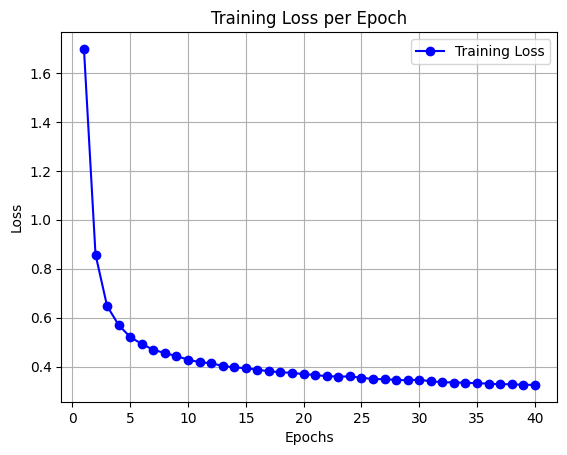

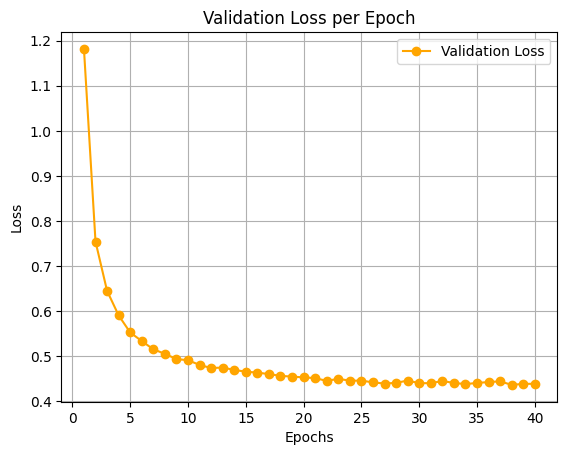

In [57]:
# # Plot both graphs
plot_training_loss(train_losses, epochs)
plot_validation_loss(val_losses, epochs)

In [59]:
def test_story_completion_batch(model, partial_stories, imgs=None, max_length=100, img_size=224):
    """
    Test the story completion task using a trained model for multiple datapoints.

    Parameters:
    - model: The trained model.
    - partial_stories: A list of input texts to start the story completion.
    - imgs: A list of image file paths or None for each story. Provide a dummy image if None.
    - max_length: Maximum length of the completed story.
    - img_size: Size to which the image should be resized.
    """
    model.eval()

    completed_stories = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Iterate through the batch of stories
    for i, partial_story in enumerate(partial_stories):
        # Encode the partial story
        encoded_partial = torch.tensor([[stoi[ch] for ch in partial_story]], dtype=torch.long).to(device)
        generated_indices = encoded_partial

        # Prepare the image tensor
        if imgs is not None and imgs[i] is not None:
            img_tensor = jpg_to_tensor(imgs[i], img_size).unsqueeze(0).to(device)
        else:
            # Create a dummy image tensor (e.g., all zeros with appropriate shape)
            img_tensor = torch.zeros(1, 3, img_size, img_size).to(device)

        # Generate the story
        for _ in range(max_length - len(partial_story)):
            # Forward pass through the model
            logits = model(img_tensor, generated_indices, None)  # Model's forward pass
            next_token = logits[:, -1].argmax(dim=-1, keepdim=True)  # Get the most likely next token

            # Append the next token to the generated indices
            generated_indices = torch.cat([generated_indices, next_token], dim=1)

            # Stop generating if a padding character or an unwanted token appears
            if next_token.item() == stoi['<pad>']:
                break

        # Decode the generated story
        completed_story = decode(generated_indices[0].tolist())
        completed_stories.append(completed_story)

    return completed_stories


# Function to test story completion with multiple datapoints
def run_story_completion_test_batch(model):
    # Example batch of partial stories
    partial_stories = [
    "The golden sun was shining bright through the big window and everything looked so warm and cozy inside ",
    "I walked into the room and saw a big chair with soft pillows sitting right next to the fireplace ",
    "The air smelled like cookies baking in the oven and I couldn’t wait to take a bite of them ",
    "The tiny birds outside the window were chirping so happily, like they were telling each other a story ",
    "There was a little cat sleeping on the fluffy rug near the fire and it looked so peaceful ",
    "Through the glass door, I saw a garden full of big colorful flowers waving gently in the wind ",
    "The room was quiet, but I could hear the ticking of a big clock hanging on the wall nearby ",
    "The sky outside was painted with orange and pink, and it looked like someone spilled colors everywhere ",
    "The soft light of the lamp made the room feel warm like a cozy little hug from the inside ",
    "The wooden floor creaked softly under my feet as I walked towards the big shelf full of books ",
    "The small swing in the garden moved back and forth slowly as the wind blew gently past it ",
    "The table had a vase with fresh flowers that smelled so nice it made the whole room feel like spring ",
    "There was a little dog wagging its tail by the door like it was waiting for someone to come inside ",
    "The sound of the waves crashing outside the window made me feel like I was standing near the ocean ",
    "The big tree outside was full of shiny green leaves that looked like they were waving hello to me ",
    "The stars were starting to twinkle in the sky, making everything outside look magical and dreamy ",
    "The tiny sparkles on the water made it look like the lake was full of little pieces of shining glass ",
    "The old rocking chair near the window looked so comfy like it was calling me to sit and rest a while ",
    "The little garden path was full of small stones that made a crunchy sound as I walked over them ",
    "The clouds in the sky were so fluffy and white they looked like cotton candy floating high up above ",
    "The soft breeze coming through the window made the curtains dance like they were alive and happy ",
    "The soft cushions on the sofa made me feel like I was sitting on a big fluffy marshmallow cloud ",
    "The tiny butterflies in the garden were flying around the flowers, their wings sparkling in the sunlight ",
    "The room smelled like fresh rain and flowers like someone had brought a piece of the garden inside ",
    "The big wooden table had a bowl full of shiny red apples that looked so delicious and juicy I wanted one "
]



    # Example: No images provided, use dummy tensors
    completed_stories = test_story_completion_batch(model, partial_stories, imgs=None, max_length=1000)

    # Print results
    for i, (partial, complete) in enumerate(zip(partial_stories, completed_stories)):
        print(f"Partial Story {i+1}: {partial}")
        print(f"Completed Story {i+1}: {complete}\n")


# Run the test with multiple datapoints
run_story_completion_test_batch(model)


Partial Story 1: The golden sun was shining bright through the big window and everything looked so warm and cozy inside 
Completed Story 1: The golden sun was shining bright through the big window and everything looked so warm and cozy inside the sun. The water sparkled light made of marble, and it feels nice to walk on. The sky was blue and fluffy with clouds, making everything look magical. It feels like a special place where the light can shine like magic. I can imagine sitting on the grass and seeing the water splashing everywhere!<pad>

Partial Story 2: I walked into the room and saw a big chair with soft pillows sitting right next to the fireplace 
Completed Story 2: I walked into the room and saw a big chair with soft pillows sitting right next to the fireplace that looks like a big bowl. There is a shiny table with a chair and a chair that is also there, waiting for someone to sit on it. The floor is made of warm wood, and it feels nice to walk on. The walls are bright white, m

In [ ]:
def test_story_completion_batch(model, partial_stories, imgs=None, max_length=100, img_size=224):
    """
    Test the story completion task using a trained model for multiple datapoints.

    Parameters:
    - model: The trained model.
    - partial_stories: A list of input texts to start the story completion.
    - imgs: A list of image file paths or None for each story. Provide a dummy image if None.
    - max_length: Maximum length of the completed story.
    - img_size: Size to which the image should be resized.
    """
    model.eval()

    completed_stories = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Iterate through the batch of stories
    for i, partial_story in enumerate(partial_stories):
        # Encode the partial story
        encoded_partial = torch.tensor([[stoi[ch] for ch in partial_story]], dtype=torch.long).to(device)
        generated_indices = encoded_partial

        # Prepare the image tensor
        if imgs is not None and imgs[i] is not None:
            img_tensor = jpg_to_tensor(imgs[i], img_size).unsqueeze(0).to(device)
        else:
            # Create a dummy image tensor (e.g., all zeros with appropriate shape)
            img_tensor = torch.zeros(1, 3, img_size, img_size).to(device)

        # Generate the story
        for _ in range(max_length - len(partial_story)):
            # Forward pass through the model
            logits = model(img_tensor, generated_indices, None)  # Model's forward pass
            next_token = logits[:, -1].argmax(dim=-1, keepdim=True)  # Get the most likely next token

            # Append the next token to the generated indices
            generated_indices = torch.cat([generated_indices, next_token], dim=1)

            # Stop generating if a padding character or an unwanted token appears
            if next_token.item() == stoi['<pad>']:
                break

        # Decode the generated story
        completed_story = decode(generated_indices[0].tolist())
        completed_stories.append(completed_story)

    return completed_stories


# Function to test story completion with multiple datapoints
def run_story_completion_test_batch(model):
    # Example batch of partial stories
    partial_stories = [
    "The gentle wind blew through the trees, making the leaves whisper secrets to each other ",
    "The warm sunlight streamed through the curtains, painting golden shapes on the wooden floor ",
    "I could see tiny birds hopping on the grass, picking at seeds and chirping with excitement ",
    "The small pond outside sparkled like it was full of tiny stars dancing on the surface ",
    "There was a big teddy bear sitting on the chair, looking like it was waiting for someone to play ",
    "The sweet smell of chocolate drifted from the kitchen, making my mouth water instantly ",
    "The colorful kites flying in the blue sky looked like happy little butterflies floating in the air ",
    "The soft blanket on the couch looked so warm and cozy, like it was waiting to wrap me up ",
    "The big clock on the wall made a soft tick-tock sound, counting each quiet second in the room ",
    "Through the open window, I could hear kids laughing and playing in the distance, filling the air with joy ",
    "The tall glass of lemonade on the table looked so refreshing, with tiny ice cubes clinking inside it ",
    "The shiny wooden staircase creaked softly as I climbed up, like it was whispering a story to me ",
    "The soft breeze brought the scent of fresh grass and wildflowers from the garden into the room ",
    "The moonlight spilled through the open window, making everything in the room glow softly like magic ",
    "The wooden chest in the corner looked old and mysterious, like it was hiding treasures from long ago ",
    "The little puppy curled up on the soft carpet looked so cute, snoring softly in its tiny dreams ",
    "The sound of crickets outside filled the quiet night, like a tiny orchestra playing just for me ",
    "The garden gate creaked open slowly, revealing a path lined with flowers and glowing in the moonlight ",
    "The shiny glass jar on the shelf was filled with colorful candies that looked too pretty to eat ",
    "The gentle ripples on the lake reflected the tall trees, making the water look like a giant mirror ",
    "The swing under the big tree swayed slowly in the wind, like it was moving on its own ",
    "The soft carpet under my feet felt warm and fuzzy, like walking on a patch of fluffy clouds ",
    "The tiny sparrow sitting on the windowsill tilted its head, as if it was curious about what I was doing ",
    "The stack of storybooks on the table looked like they were waiting for someone to dive into their world ",
    "The colorful lanterns hanging in the garden glowed softly, making the whole place look like a fairytale "
]




    # Example: No images provided, use dummy tensors
    completed_stories = test_story_completion_batch(model, partial_stories, imgs=None, max_length=1000)

    # Print results
    for i, (partial, complete) in enumerate(zip(partial_stories, completed_stories)):
        print(f"Partial Story {i+1}: {partial}")
        print(f"Completed Story {i+1}: {complete}\n")


# Run the test with multiple datapoints
run_story_completion_test_batch(model)


In [ ]:
def test_story_completion_batch(model, partial_stories, imgs=None, max_length=100, img_size=224):
    """
    Test the story completion task using a trained model for multiple datapoints.

    Parameters:
    - model: The trained model.
    - partial_stories: A list of input texts to start the story completion.
    - imgs: A list of image file paths or None for each story. Provide a dummy image if None.
    - max_length: Maximum length of the completed story.
    - img_size: Size to which the image should be resized.
    """
    model.eval()

    completed_stories = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Iterate through the batch of stories
    for i, partial_story in enumerate(partial_stories):
        # Encode the partial story
        encoded_partial = torch.tensor([[stoi[ch] for ch in partial_story]], dtype=torch.long).to(device)
        generated_indices = encoded_partial

        # Prepare the image tensor
        if imgs is not None and imgs[i] is not None:
            img_tensor = jpg_to_tensor(imgs[i], img_size).unsqueeze(0).to(device)
        else:
            # Create a dummy image tensor (e.g., all zeros with appropriate shape)
            img_tensor = torch.zeros(1, 3, img_size, img_size).to(device)

        # Generate the story
        for _ in range(max_length - len(partial_story)):
            # Forward pass through the model
            logits = model(img_tensor, generated_indices, None)  # Model's forward pass
            next_token = logits[:, -1].argmax(dim=-1, keepdim=True)  # Get the most likely next token

            # Append the next token to the generated indices
            generated_indices = torch.cat([generated_indices, next_token], dim=1)

            # Stop generating if a padding character or an unwanted token appears
            if next_token.item() == stoi['<pad>']:
                break

        # Decode the generated story
        completed_story = decode(generated_indices[0].tolist())
        completed_stories.append(completed_story)

    return completed_stories


# Function to test story completion with multiple datapoints
def run_story_completion_test_batch(model):
    # Example batch of partial stories
    partial_stories = [
        "I can’t believe my eyes! This place looks magical, like something out of a fairytale! ",
        "The room was dimly lit, yet every corner sparkled with a mysterious glow. ",
        "As I stepped inside, the aroma of fresh flowers overwhelmed my senses. ",
        "The walls were lined with bookshelves, each filled with volumes that seemed ancient and wise. ",
        "Through the open window, I could hear the distant sound of waves crashing on the shore. ",
        "The fireplace crackled gently, casting a warm light across the room. ",
        "Outside, the snow fell silently, covering the world in a blanket of white. ",
        "The garden beyond the glass doors looked like a dream, alive with colors and fragrance. ",
        "In the center of the room, a grand piano stood, inviting me to play a tune. "
    ]

    # Example: No images provided, use dummy tensors
    completed_stories = test_story_completion_batch(model, partial_stories, imgs=None, max_length=1000)

    # Print results
    for i, (partial, complete) in enumerate(zip(partial_stories, completed_stories)):
        print(f"Partial Story {i+1}: {partial}")
        print(f"Completed Story {i+1}: {complete}\n")


# Run the test with multiple datapoints
run_story_completion_test_batch(model)


In [ ]:
from google.colab import files
import shutil

# Original file path of the .pth model on Colab
original_path = '/content/latest_model.pth'  # Replace with your model's actual path

# New file name for the model
renamed_path = '/content/NanoVLMlarge_LongDesc_25M.pth'

# Rename the file
shutil.move(original_path, renamed_path)


# Download the renamed file
files.download(renamed_path)
